In [2]:
# IMPORTS

# --- Core Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Statistics ---
from scipy import stats
from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    mannwhitneyu,
    f_oneway
)
from statsmodels.stats.proportion import proportions_ztest

# --- Warnings ---
import warnings
warnings.filterwarnings('ignore')
# --- Display Settings ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

In [3]:
# LOAD DATA

# --- Main Events Data ---
df = pd.read_csv("clean_events.csv")

# --- Feature Tables ---
features_master = pd.read_csv("features_master.csv")
session_features = pd.read_csv("session_features.csv")

# --- Hypothesis Test Data (from SQL) ---
hypothesis_data = pd.read_csv("hypothesis_test_data.csv")

# --- Quick Shape Check ---
print("Events shape          :", df.shape)
print("Features shape        :", features_master.shape)
print("Session shape         :", session_features.shape)
print("Hypothesis data shape :", hypothesis_data.shape)

# --- Column Check ---
print("\nHypothesis data columns:")
print(hypothesis_data.columns.tolist())

# --- Preview Data ---
print("\nHypothesis data preview:")
display(hypothesis_data.head())

Events shape          : (2755641, 12)
Features shape        : (1407580, 29)
Session shape         : (1761675, 16)
Hypothesis data shape : (1941974, 17)

Hypothesis data columns:
['visitorid', 'total_sessions', 'total_events', 'total_views', 'total_carts', 'total_purchases', 'has_purchased', 'has_cart', 'hour_of_day', 'day_of_week', 'is_weekend', 'avg_session_depth', 'categoryid', 'buyer_label', 'time_of_day_label', 'day_type_label', 'session_depth_score']

Hypothesis data preview:


,visitorid,total_sessions,total_events,total_views,total_carts,total_purchases,has_purchased,has_cart,hour_of_day,day_of_week,is_weekend,avg_session_depth,categoryid,buyer_label,time_of_day_label,day_type_label,session_depth_score
0,0,1,1,1,0,0,0,0,2,6,1,1,256,Non-Buyer,Night,Weekend,1
1,0,1,1,1,0,0,0,0,2,6,1,1,333,Non-Buyer,Night,Weekend,1
2,0,1,1,1,0,0,0,0,2,6,1,1,1188,Non-Buyer,Night,Weekend,1
3,1,1,1,1,0,0,0,0,23,4,0,1,1192,Non-Buyer,Evening,Weekday,1
4,2,1,3,3,0,0,0,0,0,6,1,3,299,Non-Buyer,Night,Weekend,3


In [4]:
# FIX DATA TYPES

# --- Convert datetime ---
df['event_datetime'] = pd.to_datetime(df['event_datetime'], format='mixed')

# --- Remove timezone if exists ---
if df['event_datetime'].dt.tz is not None:
    df['event_datetime'] = df['event_datetime'].dt.tz_convert(None)

# --- Convert IDs to string ---
df['visitorid'] = df['visitorid'].astype(str)
df['session_id'] = df['session_id'].astype(str)
df['itemid'] = df['itemid'].astype(str)
hypothesis_data['visitorid'] = hypothesis_data['visitorid'].astype(str)

# --- Check label distributions ---
print("Buyer label values:")
print(hypothesis_data['buyer_label'].value_counts())

print("\nTime of day label values:")
print(hypothesis_data['time_of_day_label'].value_counts())

print("\nDay type label values:")
print(hypothesis_data['day_type_label'].value_counts())

Buyer label values:
buyer_label
Non-Buyer    1921377
Buyer          20597
Name: count, dtype: int64

Time of day label values:
time_of_day_label
Night        749098
Morning      595164
Evening      452581
Afternoon    145131
Name: count, dtype: int64

Day type label values:
day_type_label
Weekday    1479321
Weekend     462653
Name: count, dtype: int64


In [7]:
# P-VALUE GUIDE

print("=" * 50)
print("P-VALUE INTERPRETATION GUIDE")
print("=" * 50)
print("p < 0.01  → Very strong evidence against H0")
print("p < 0.05  → Strong evidence (our alpha level)")
print("p < 0.10  → Weak evidence against H0")
print("p >= 0.10 → Insufficient evidence to reject H0")
print("=" * 50)
print("Alpha (significance level) = 0.05")
print("=" * 50)

P-VALUE INTERPRETATION GUIDE
p < 0.01  → Very strong evidence against H0
p < 0.05  → Strong evidence (our alpha level)
p < 0.10  → Weak evidence against H0
p >= 0.10 → Insufficient evidence to reject H0
Alpha (significance level) = 0.05


In [8]:
# ============================================================
# TEST 1: INDEPENDENT T-TEST

# --- Business Question ---
# Do buyers view more items than non-buyers before purchase?

# H0: Buyers and non-buyers have equal average view count
# H1: Buyers view significantly more items
# Method: Independent t-test
# Why: Comparing means of 2 independent groups
# ============================================================

# --- Hypothesis Groups ---
buyers = hypothesis_data[hypothesis_data['buyer_label'] == 'Buyer']['total_views']
non_buyers = hypothesis_data[hypothesis_data['buyer_label'] == 'Non-Buyer']['total_views']

# --- Assumption Check ---
print("--- Assumptions Check ---")
print("Buyers sample size     :", len(buyers))
print("Non-buyers sample size :", len(non_buyers))
print("Large samples → CLT applies")

# --- T-Test ---
t_stat, p_value = ttest_ind(buyers, non_buyers, equal_var=False)

# --- Results ---
print("=" * 50)
print("TEST 1: INDEPENDENT T-TEST RESULTS")
print("=" * 50)

print("Buyers avg views     :", round(buyers.mean(), 2))
print("Non-buyers avg views :", round(non_buyers.mean(), 2))
print("Difference           :", round(buyers.mean() - non_buyers.mean(), 2))

print("T-Statistic          :", round(t_stat, 4))
print("P-Value              :", round(p_value, 6))

# --- Conclusion ---
print("\nStatistical Conclusion:")
if p_value < 0.05:
    print("Reject H0 → Buyers view more items")
else:
    print("Fail to Reject H0 → No significant difference")

print("\nBusiness Insight:")
print("More views → higher purchase likelihood")
print("→ Recommend more related products to engaged users")

--- Assumptions Check ---
Buyers sample size     : 20597
Non-buyers sample size : 1921377
Large samples → CLT applies
TEST 1: INDEPENDENT T-TEST RESULTS
Buyers avg views     : 1.79
Non-buyers avg views : 1.37
Difference           : 0.42
T-Statistic          : 27.249
P-Value              : 0.0

Statistical Conclusion:
Reject H0 → Buyers view more items

Business Insight:
More views → higher purchase likelihood
→ Recommend more related products to engaged users


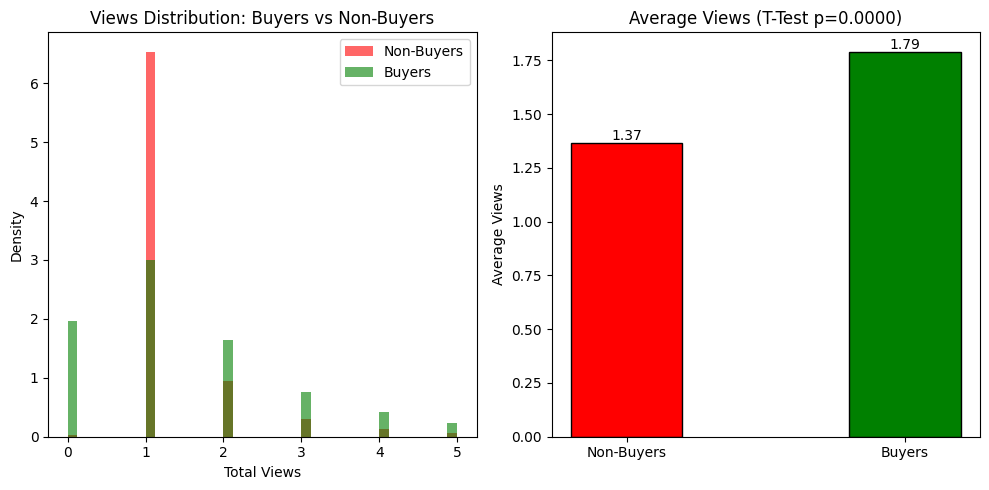

In [10]:
# ============================================================
# TEST 1: VISUALIZATION
# ============================================================

# --- Cap extreme values for clean plot ---
cap = features_master['total_views'].quantile(0.95)

buyers_plot = buyers[buyers <= cap]
non_buyers_plot = non_buyers[non_buyers <= cap]

plt.figure(figsize=(10, 5))

# --- Distribution Comparison ---
plt.subplot(1, 2, 1)
plt.hist(non_buyers_plot, bins=40, alpha=0.6, color='red', label='Non-Buyers', density=True)
plt.hist(buyers_plot, bins=40, alpha=0.6, color='green', label='Buyers', density=True)

plt.title('Views Distribution: Buyers vs Non-Buyers')
plt.xlabel('Total Views')
plt.ylabel('Density')
plt.legend()

# --- Mean Comparison ---
plt.subplot(1, 2, 2)

means = [non_buyers.mean(), buyers.mean()]
labels = ['Non-Buyers', 'Buyers']
colors = ['red', 'green']

bars = plt.bar(labels, means, color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars, means):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:.2f}',
        ha='center',
        va='bottom'
    )

plt.title(f'Average Views (T-Test p={p_value:.4f})')
plt.ylabel('Average Views')

plt.tight_layout()
plt.savefig('test1_ttest.png', dpi=150)
plt.show()

In [12]:
# ============================================================
# TEST 2: CHI-SQUARE TEST
# Business Question:
# Is purchase behavior independent of time of day?

# H0: Event type and time of day are statistically independent
# H1: Purchase behavior depends significantly on time of day

# Method: Chi-square contingency test
# Why: Two categorical variables
# ============================================================



# --- Contingency Table ---
contingency = pd.crosstab(
    hypothesis_data['time_of_day_label'],
    hypothesis_data['has_purchased']
)

print("--- Contingency Table ---")
print(contingency)

# --- Chi-Square Test ---
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency)

# --- Results ---
print("=" * 50)
print("TEST 2: CHI-SQUARE TEST RESULTS")
print("=" * 50)

print("Chi2 Statistic     :", round(chi2_stat, 4))
print("Degrees of Freedom :", dof)
print("P-Value            :", round(p_value_chi2, 6))

# --- Conclusion ---
print("\nStatistical Conclusion:")
if p_value_chi2 < 0.05:
    print("Reject H0 → Purchase depends on time of day")
else:
    print("Fail to Reject H0 → No dependency")

print("\nBusiness Insight:")
print("Use time-based targeting for promotions")
print("Focus ads on high-conversion hours")

--- Contingency Table ---
has_purchased           0     1
time_of_day_label              
Afternoon          144179   952
Evening            447516  5065
Morning            590121  5043
Night              739561  9537
TEST 2: CHI-SQUARE TEST RESULTS
Chi2 Statistic     : 821.6405
Degrees of Freedom : 3
P-Value            : 0.0

Statistical Conclusion:
Reject H0 → Purchase depends on time of day

Business Insight:
Use time-based targeting for promotions
Focus ads on high-conversion hours


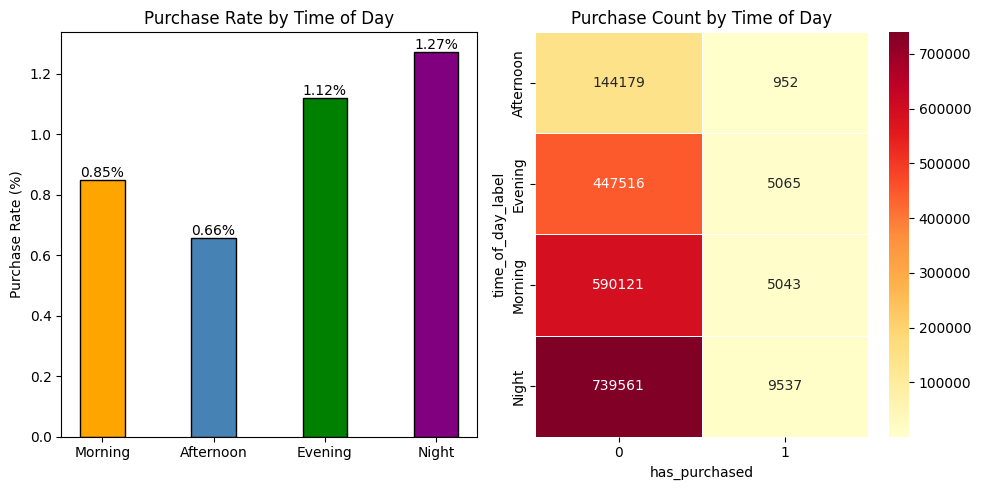

In [21]:
# ============================================================
# TEST 2: VISUALIZATION (HYPOTHESIS DATA)
# ============================================================

# --- Purchase Rate by Time of Day ---
purchase_by_time = (hypothesis_data.groupby('time_of_day_label')['has_purchased'].mean().reset_index(name='purchase_rate'))

# --- Sort Time Order ---
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
purchase_by_time['time_of_day_label'] = pd.Categorical(purchase_by_time['time_of_day_label'], categories=time_order, ordered=True)
purchase_by_time = purchase_by_time.sort_values('time_of_day_label')

plt.figure(figsize=(10, 5))

# --- Bar Chart: Purchase Rate ---
plt.subplot(1, 2, 1)

bars = plt.bar(
    purchase_by_time['time_of_day_label'],
    purchase_by_time['purchase_rate'] * 100,
    color=['orange', 'steelblue', 'green', 'purple'],
    edgecolor='black',
    width=0.4
)

for bar, val in zip(bars, purchase_by_time['purchase_rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val*100:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Purchase Rate by Time of Day')
plt.ylabel('Purchase Rate (%)')

# --- Contingency Heatmap ---
plt.subplot(1, 2, 2)

contingency = pd.crosstab(hypothesis_data['time_of_day_label'], hypothesis_data['has_purchased'])

sns.heatmap(
    contingency,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Purchase Count by Time of Day')

plt.tight_layout()
plt.savefig('test2_chisquare.png', dpi=150)
plt.show()

In [22]:
# ============================================================
# TEST 3: TWO-PROPORTION Z-TEST
# Business Question:
# Is weekday CVR statistically different from weekend CVR?

# H0: CVR_weekday = CVR_weekend
# H1: CVR_weekday ≠ CVR_weekend

# Method: Two-proportion z-test
# Why: Comparing two proportions
# ============================================================

# --- Split Data ---
weekday_data = hypothesis_data[hypothesis_data['day_type_label'] == 'Weekday']
weekend_data = hypothesis_data[hypothesis_data['day_type_label'] == 'Weekend']

# --- Conversions ---
weekday_conv = weekday_data['has_purchased'].sum()
weekend_conv = weekend_data['has_purchased'].sum()
weekday_total = len(weekday_data)
weekend_total = len(weekend_data)

# --- CVR ---
weekday_cvr = weekday_conv / weekday_total
weekend_cvr = weekend_conv / weekend_total
# --- Z-Test ---
count = np.array([weekday_conv, weekend_conv])
nobs  = np.array([weekday_total, weekend_total])

z_stat, p_value_z = proportions_ztest(count, nobs)

# --- Results ---
print("=" * 50)
print("TEST 3: TWO-PROPORTION Z-TEST RESULTS")
print("=" * 50)

print("Weekday users :", weekday_total)
print("Weekend users :", weekend_total)

print("Weekday CVR   :", round(weekday_cvr * 100, 4), "%")
print("Weekend CVR   :", round(weekend_cvr * 100, 4), "%")

print("Z-Statistic   :", round(z_stat, 4))
print("P-Value       :", round(p_value_z, 6))

# --- Conclusion ---
print("\nStatistical Conclusion:")
if p_value_z < 0.05:
    print("Reject H0 → Weekday vs Weekend CVR is different")
else:
    print("Fail to Reject H0 → No significant difference")

print("\nBusiness Insight:")
print("Adjust marketing spend based on higher CVR day type")

TEST 3: TWO-PROPORTION Z-TEST RESULTS
Weekday users : 1479321
Weekend users : 462653
Weekday CVR   : 1.1321 %
Weekend CVR   : 0.8322 %
Z-Statistic   : 17.3809
P-Value       : 0.0

Statistical Conclusion:
Reject H0 → Weekday vs Weekend CVR is different

Business Insight:
Adjust marketing spend based on higher CVR day type


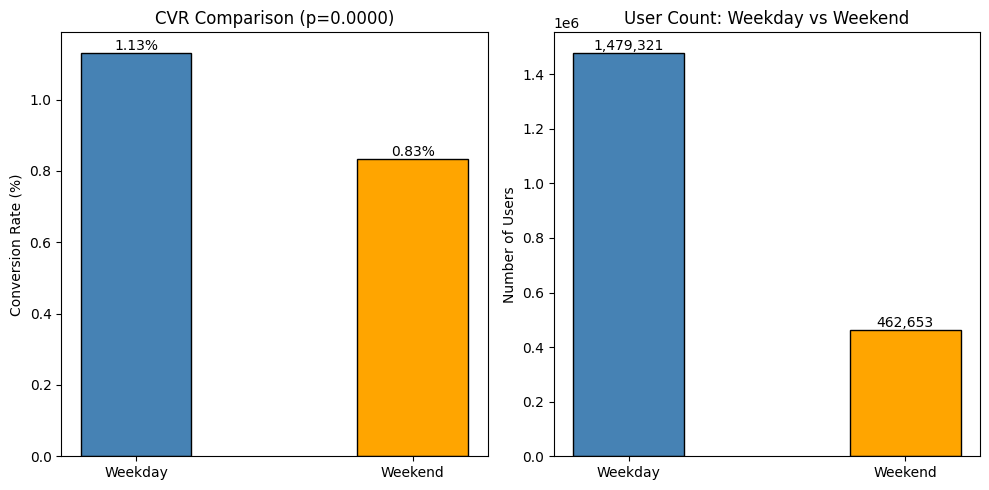

In [23]:

# ============================================================
# TEST 3: VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

# --- CVR Comparison ---
plt.subplot(1, 2, 1)

labels = ['Weekday', 'Weekend']
values = [weekday_cvr * 100, weekend_cvr * 100]
colors = ['steelblue', 'orange']

bars = plt.bar(labels, values, color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title(f'CVR Comparison (p={p_value_z:.4f})')
plt.ylabel('Conversion Rate (%)')

# --- User Count Comparison ---
plt.subplot(1, 2, 2)

bars2 = plt.bar(labels, [weekday_total, weekend_total], color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars2, [weekday_total, weekend_total]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:,}',
        ha='center',
        va='bottom'
    )

plt.title('User Count: Weekday vs Weekend')
plt.ylabel('Number of Users')

plt.tight_layout()
plt.savefig('test3_ztest.png', dpi=150)
plt.show()



In [24]:
# ============================================================
# TEST 4: MANN-WHITNEY U TEST
# ============================================================

# --- Business Question ---
# Do deeper sessions lead to higher conversion?

# --- Hypotheses ---
# H0: Session depth does not affect conversion probability
# H1: Deeper sessions convert more

# --- Method ---
# Mann-Whitney U test (non-parametric, non-normal data)

# ============================================================

# --- Data (SQL prepared) ---
converted = hypothesis_data[ hypothesis_data['has_purchased'] == 1 ]['avg_session_depth'].dropna()
not_converted = hypothesis_data[hypothesis_data['has_purchased'] == 0]['avg_session_depth'].dropna()

# --- Mann-Whitney U Test ---
mw_stat, p_value_mw = mannwhitneyu(converted,not_converted,alternative='greater')

# --- Results ---
print("=" * 50)
print("TEST 4: MANN-WHITNEY U TEST RESULTS")
print("=" * 50)

print("Converted users     :", len(converted))
print("Not converted users :", len(not_converted))

print("Median depth (converted)    :", round(converted.median(), 2))
print("Median depth (not converted):", round(not_converted.median(), 2))

print("U-Statistic :", round(mw_stat, 4))
print("P-Value     :", round(p_value_mw, 6))

# --- Conclusion ---
print("\nStatistical Conclusion:")
if p_value_mw < 0.05:
    print("Reject H0 → Deeper sessions increase conversion")
else:
    print("Fail to Reject H0 → No strong evidence")

print("\nBusiness Insight:")
print("Improve engagement inside sessions")
print("Use recommendations and guided browsing")

TEST 4: MANN-WHITNEY U TEST RESULTS
Converted users     : 20597
Not converted users : 1921377
Median depth (converted)    : 3.0
Median depth (not converted): 1.0
U-Statistic : 34277229689.5
P-Value     : 0.0

Statistical Conclusion:
Reject H0 → Deeper sessions increase conversion

Business Insight:
Improve engagement inside sessions
Use recommendations and guided browsing


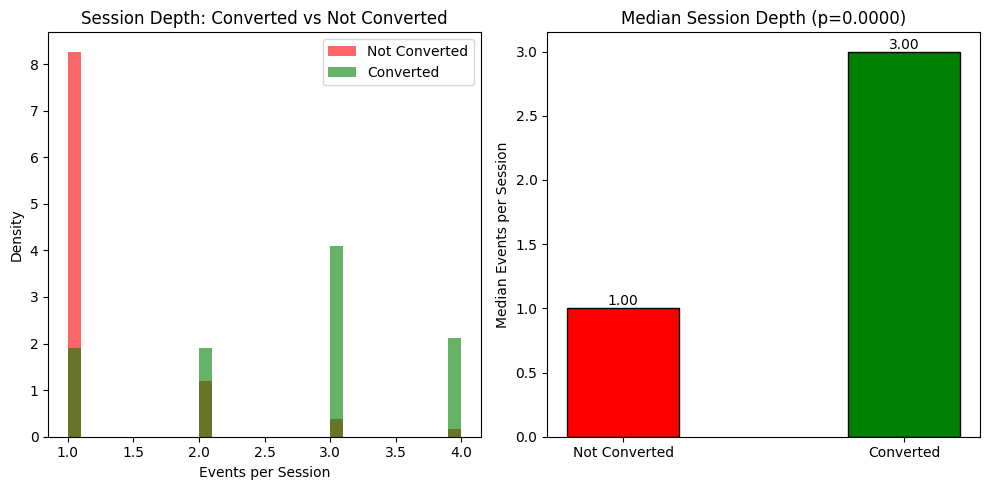

In [25]:
# ============================================================
# FIX: RECREATE SESSION MERGED DATA
# ============================================================

session_merged = session_features.merge(
    features_master[['visitorid', 'has_purchased']],
    on='visitorid',
    how='left'
)

# ============================================================
# TEST 4: VISUALIZATION
# ============================================================

# --- Cap for clean visualization ---
cap = session_merged['events_per_session'].quantile(0.95)

conv_plot = converted[converted <= cap]
not_conv_plot = not_converted[not_converted <= cap]

plt.figure(figsize=(10, 5))

# --- Distribution Comparison ---
plt.subplot(1, 2, 1)

plt.hist(not_conv_plot, bins=30, alpha=0.6, color='red', label='Not Converted', density=True)

plt.hist(conv_plot, bins=30, alpha=0.6, color='green', label='Converted', density=True)

plt.title('Session Depth: Converted vs Not Converted')
plt.xlabel('Events per Session')
plt.ylabel('Density')
plt.legend()

# --- Median Comparison ---
plt.subplot(1, 2, 2)

medians = [not_converted.median(), converted.median()]
labels = ['Not Converted', 'Converted']
colors = ['red', 'green']

bars = plt.bar(labels, medians, color=colors, edgecolor='black', width=0.4)

for bar, val in zip(bars, medians):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:.2f}',
        ha='center',
        va='bottom'
    )

plt.title(f'Median Session Depth (p={p_value_mw:.4f})')
plt.ylabel('Median Events per Session')

plt.tight_layout()
plt.savefig('test4_mannwhitney.png', dpi=150)
plt.show()

In [26]:
# ============================================================
# TEST 5: ONE-WAY ANOVA
# ============================================================

# --- Business Question ---
# Do product categories have equal engagement?

# --- Hypotheses ---
# H0: All categories have equal mean engagement
# H1: At least one category differs

# --- Method ---
# One-way ANOVA (3+ group mean comparison)

# ============================================================

# --- Category-wise item views ---
category_views = (df[df['event_type'] == 'view'].groupby(['categoryid', 'itemid']).size().reset_index(name='item_views'))
# --- Top categories ---
top_categories = (category_views.groupby('categoryid')['item_views'].count().nlargest(10).index.tolist())
# --- Filter top categories ---
category_views_top = category_views[category_views['categoryid'].isin(top_categories)]
# --- ANOVA groups ---
groups = [group['item_views'].values for _, group in category_views_top.groupby('categoryid')] 
# --- ANOVA Test ---
f_stat, p_value_anova = f_oneway(*groups)
# --- Category Summary ---
category_stats = (category_views_top.groupby('categoryid')['item_views'].agg(['mean', 'median', 'count']).reset_index().sort_values('mean', ascending=False))

# --- Results ---
print("=" * 50)
print("TEST 5: ONE-WAY ANOVA RESULTS")
print("=" * 50)

print("Categories tested :", len(top_categories))
print("F-Statistic       :", round(f_stat, 4))
print("P-Value           :", round(p_value_anova, 6))

print("\nCategory Stats:")
print(category_stats.to_string(index=False))

# --- Conclusion ---
print("\nStatistical Conclusion:")
if p_value_anova < 0.05:
    print("Reject H0 → Category engagement differs")
else:
    print("Fail to Reject H0 → No significant difference")

print("\nBusiness Insight:")
print("Improve low-performing categories")
print("Increase visibility of weak categories")
print("Optimize content and recommendation system")

TEST 5: ONE-WAY ANOVA RESULTS
Categories tested : 10
F-Statistic       : 536.2829
P-Value           : 0.0

Category Stats:
 categoryid      mean  median  count
       1051 28.554556     6.0   2557
        959 26.514286     6.0   1890
        491 24.543874     5.0   2416
       1483 21.319185     5.0   2945
        342  9.643952     2.0   4696
        242  7.872993     3.0   2118
         -1  5.104348     2.0  49814
        769  3.194648     2.0   3961
       1680  2.709967     2.0   2117
       1007  2.090616     1.0   2174

Statistical Conclusion:
Reject H0 → Category engagement differs

Business Insight:
Improve low-performing categories
Increase visibility of weak categories
Optimize content and recommendation system


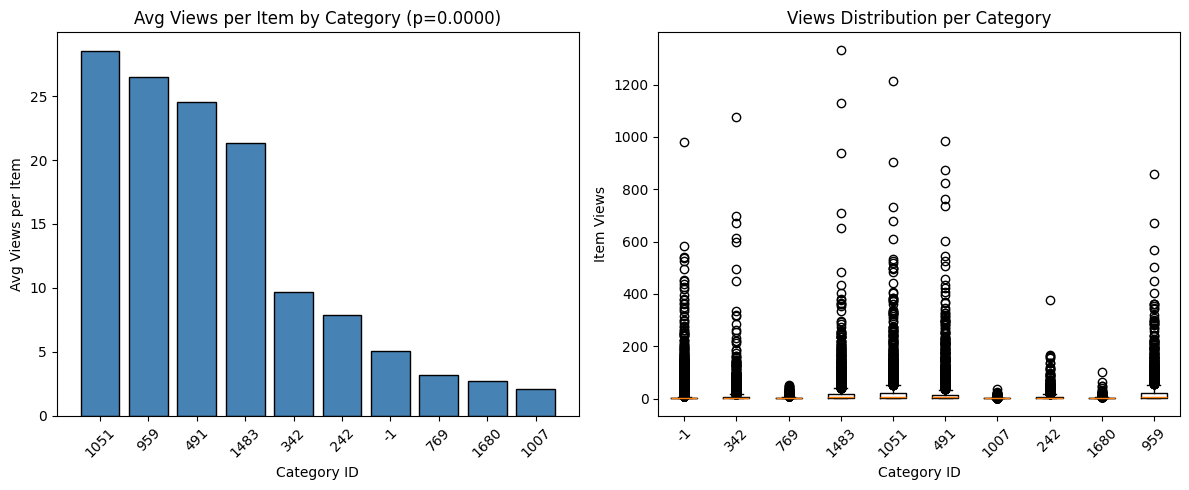

In [27]:
# ============================================================
# TEST 5: VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 5))

# --- Mean Views per Category ---
plt.subplot(1, 2, 1)

bars = plt.bar(
    category_stats['categoryid'].astype(str),
    category_stats['mean'],
    color='steelblue',
    edgecolor='black'
)

plt.title(f'Avg Views per Item by Category (p={p_value_anova:.4f})')
plt.xlabel('Category ID')
plt.ylabel('Avg Views per Item')
plt.xticks(rotation=45)

# --- Boxplot per Category ---
plt.subplot(1, 2, 2)

box_data = [
    category_views_top[
        category_views_top['categoryid'] == cat
    ]['item_views'].values
    for cat in top_categories
]

plt.boxplot(
    box_data,
    labels=[str(c) for c in top_categories]
)

plt.title('Views Distribution per Category')
plt.xlabel('Category ID')
plt.ylabel('Item Views')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('test5_anova.png', dpi=150)
plt.show()

In [28]:
# ============================================================
# SECTION 6: HYPOTHESIS TEST SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    'test_number': [1, 2, 3, 4, 5],
    'test_name': [
        'Independent T-Test',
        'Chi-Square Test',
        'Two-Proportion Z-Test',
        'Mann-Whitney U Test',
        'One-Way ANOVA'
    ],
    'business_question': [
        'Do buyers view more items than non-buyers?',
        'Is purchase behavior independent of time?',
        'Is weekday CVR different from weekend CVR?',
        'Do deeper sessions lead to more conversion?',
        'Do all categories have equal engagement?'
    ],
    'h0': [
        'Equal avg views',
        'Event type independent of time',
        'CVR_weekday = CVR_weekend',
        'Session depth does not affect CVR',
        'All categories equal engagement'
    ],
    'p_value': [
        p_value,
        p_value_chi2,
        p_value_z,
        p_value_mw,
        p_value_anova
    ],
    'significant': [
        p_value < 0.05,
        p_value_chi2 < 0.05,
        p_value_z < 0.05,
        p_value_mw < 0.05,
        p_value_anova < 0.05
    ],
    'verdict': [
        'Reject H0' if p_value < 0.05 else 'Fail to Reject',
        'Reject H0' if p_value_chi2 < 0.05 else 'Fail to Reject',
        'Reject H0' if p_value_z < 0.05 else 'Fail to Reject',
        'Reject H0' if p_value_mw < 0.05 else 'Fail to Reject',
        'Reject H0' if p_value_anova < 0.05 else 'Fail to Reject'
    ]
})

# --- Output ---
print("=" * 70)
print("HYPOTHESIS TEST SUMMARY")
print("=" * 70)
print(summary.to_string(index=False))

HYPOTHESIS TEST SUMMARY
 test_number             test_name                           business_question                                h0       p_value  significant   verdict
           1    Independent T-Test  Do buyers view more items than non-buyers?                   Equal avg views 1.151550e-160         True Reject H0
           2       Chi-Square Test   Is purchase behavior independent of time?    Event type independent of time 8.766729e-178         True Reject H0
           3 Two-Proportion Z-Test  Is weekday CVR different from weekend CVR?         CVR_weekday = CVR_weekend  1.151230e-67         True Reject H0
           4   Mann-Whitney U Test Do deeper sessions lead to more conversion? Session depth does not affect CVR  0.000000e+00         True Reject H0
           5         One-Way ANOVA    Do all categories have equal engagement?   All categories equal engagement  0.000000e+00         True Reject H0


In [29]:
# ============================================================
# SECTION 7: EXPORT
# ============================================================

# Save summary
summary.to_csv("hypothesis_results.csv", index=False)

print("hypothesis_results.csv →", len(summary), "tests")
print(summary[['test_name', 'p_value', 'significant', 'verdict']])

hypothesis_results.csv → 5 tests
               test_name        p_value  significant    verdict
0     Independent T-Test  1.151550e-160         True  Reject H0
1        Chi-Square Test  8.766729e-178         True  Reject H0
2  Two-Proportion Z-Test   1.151230e-67         True  Reject H0
3    Mann-Whitney U Test   0.000000e+00         True  Reject H0
4          One-Way ANOVA   0.000000e+00         True  Reject H0
